In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('Online Retail.xlsx')
print(df.shape)
print(df.columns.tolist())
df.head()

(541909, 8)
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# drop missing CustomerIDs
df = df.dropna(subset=['CustomerID'])

# remove cancellations (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# remove negative or zero quantity/price
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# fix dtypes
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# confirm
print(df.shape)
print(df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())

(397884, 8)
2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [5]:
from operator import attrgetter

In [7]:
# create revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# get each customer's first purchase month (their cohort)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# calculate months since first purchase
df['CohortIndex'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(attrgetter('n'))

# check it
df[['CustomerID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].head(10)

,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,17850,2010-12,2010-12,0
1,17850,2010-12,2010-12,0
2,17850,2010-12,2010-12,0
3,17850,2010-12,2010-12,0
4,17850,2010-12,2010-12,0
5,17850,2010-12,2010-12,0
6,17850,2010-12,2010-12,0
7,17850,2010-12,2010-12,0
8,17850,2010-12,2010-12,0
9,13047,2010-12,2010-12,0


In [9]:
# count unique customers per cohort and cohort index
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

# pivot into matrix
cohort_matrix = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# retention rates - divide every column by cohort starting size (column 0)
retention_matrix = cohort_matrix.divide(cohort_matrix[0], axis=0).round(3)

print(cohort_matrix.shape)
retention_matrix

(13, 13)


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366,0.323,0.384,0.363,0.398,0.363,0.349,0.354,0.395,0.374,0.503,0.266
2011-01,1.0,0.221,0.266,0.230,0.321,0.288,0.247,0.242,0.300,0.326,0.365,0.118,NaN
2011-02,1.0,0.187,0.187,0.284,0.271,0.247,0.253,0.279,0.247,0.305,0.068,NaN,NaN
2011-03,1.0,0.150,0.252,0.199,0.223,0.168,0.268,0.230,0.279,0.086,NaN,NaN,NaN
2011-04,1.0,0.213,0.203,0.210,0.197,0.227,0.217,0.260,0.073,NaN,NaN,NaN,NaN
2011-05,1.0,0.190,0.173,0.173,0.208,0.232,0.264,0.095,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.174,0.157,0.264,0.231,0.335,0.095,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.181,0.207,0.223,0.271,0.112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207,0.249,0.243,0.124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print(df['InvoiceDate'].max())
print(df[df['InvoiceDate'].dt.to_period('M') == '2011-12']['CustomerID'].nunique())
print(df[df['InvoiceDate'].dt.to_period('M') == '2011-11']['CustomerID'].nunique())

2011-12-09 12:50:00
615
1664


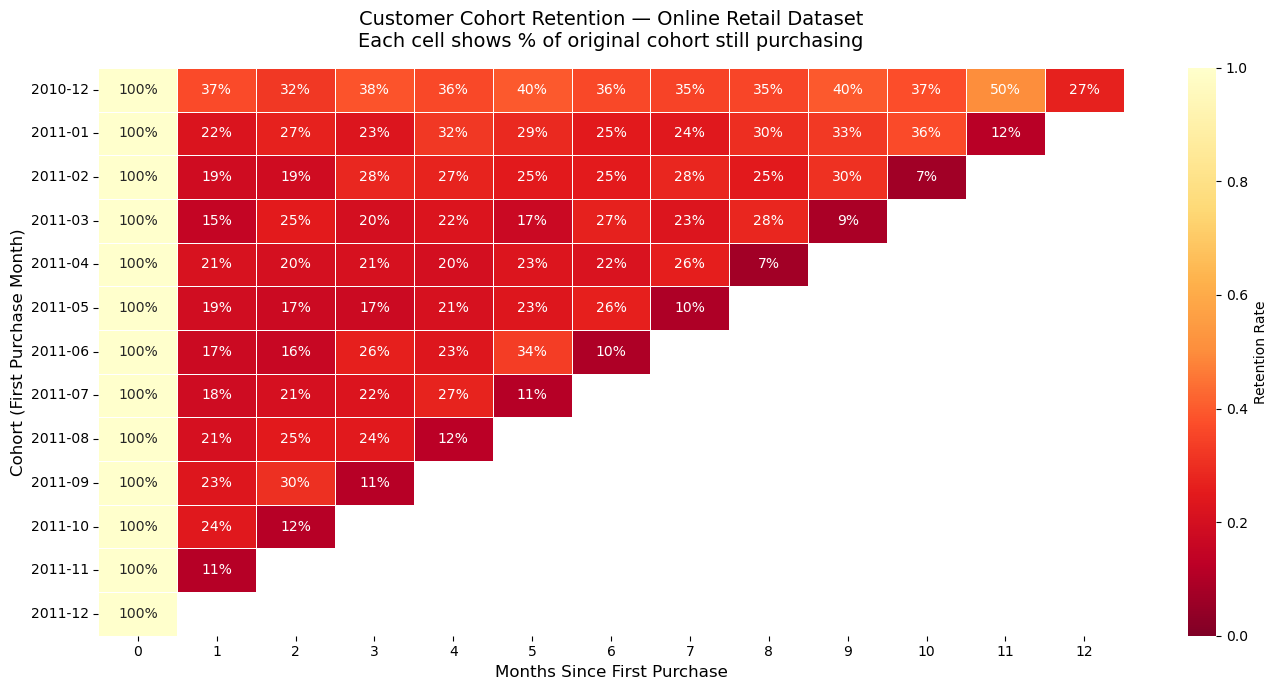

In [13]:
# "December 2011 contains only 9 days of transactions and 615 unique customers — roughly 37% of a typical month's volume. This compressed observation window explains why NaN values extend beyond just the final cohort row, affecting November and October cohorts' later-period retention as well. These cells should be interpreted as 'insufficient data' rather than zero retention."
plt.figure(figsize=(14, 7))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.0%',
    cmap='YlOrRd_r',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate'}
)

plt.title('Customer Cohort Retention — Online Retail Dataset\nEach cell shows % of original cohort still purchasing', 
          fontsize=14, pad=15)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort (First Purchase Month)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

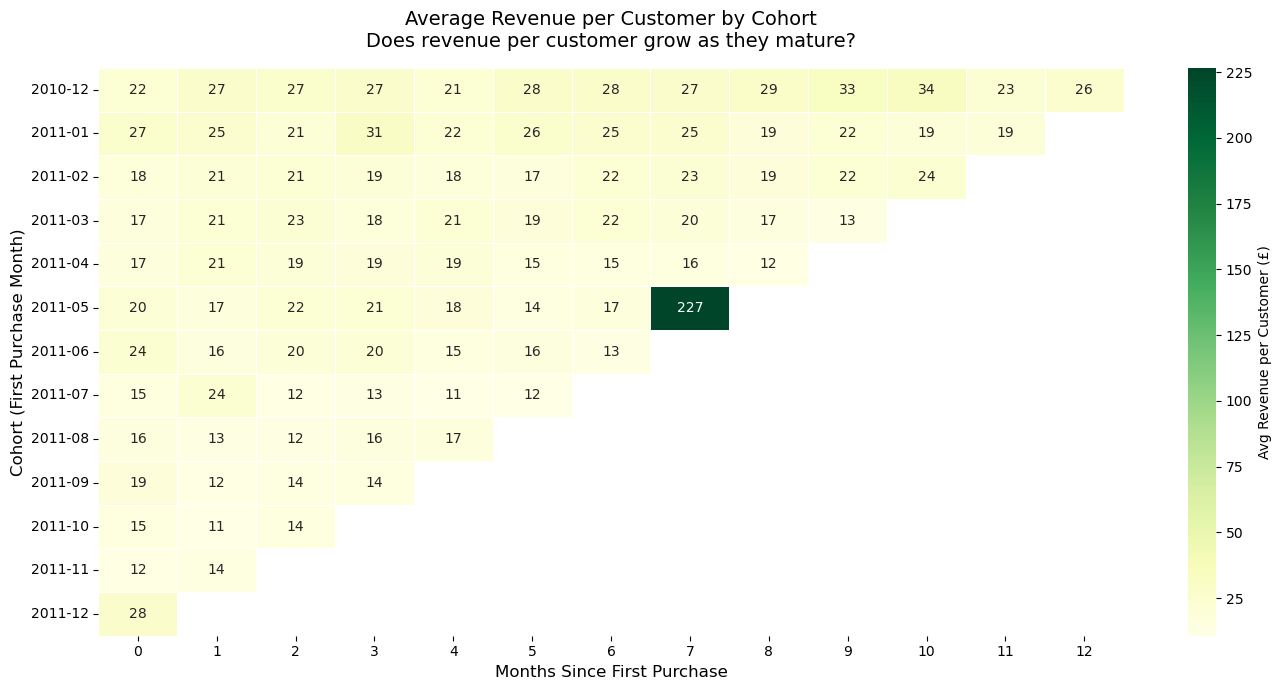

In [15]:
# average revenue per customer per cohort month
revenue_data = df.groupby(['CohortMonth', 'CohortIndex'])['Revenue'].mean().reset_index()

revenue_matrix = revenue_data.pivot(index='CohortMonth', columns='CohortIndex', values='Revenue').round(2)

plt.figure(figsize=(14, 7))

sns.heatmap(
    revenue_matrix,
    annot=True,
    fmt='.0f',
    cmap='YlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Avg Revenue per Customer (£)'}
)

plt.title('Average Revenue per Customer by Cohort\nDoes revenue per customer grow as they mature?',
          fontsize=14, pad=15)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort (First Purchase Month)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('revenue_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
mask = (df['CohortMonth'] == '2011-05') & (df['CohortIndex'] == 7)
suspect = df[mask]
print(suspect.shape)
print(suspect.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10))

(791, 12)
CustomerID
16446    168469.60
12700      1314.75
15123      1129.84
16440       975.43
15187       832.48
12749       763.06
12562       654.37
14649       513.99
15907       437.93
14397       429.20
Name: Revenue, dtype: float64


In [19]:
# remove customers whose total revenue exceeds a threshold
customer_revenue = df.groupby('CustomerID')['Revenue'].sum()
valid_customers = customer_revenue[customer_revenue < 10000].index
df_clean = df[df['CustomerID'].isin(valid_customers)]
print(df_clean['CustomerID'].nunique(), 'customers remaining')

4234 customers remaining


In [25]:
# rebuild cohort matrices on clean data
cohort_data_clean = df_clean.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_matrix_clean = cohort_data_clean.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')
retention_matrix_clean = cohort_matrix_clean.divide(cohort_matrix_clean[0], axis=0).round(3)

revenue_data_clean = df_clean.groupby(['CohortMonth', 'CohortIndex'])['Revenue'].mean().reset_index()
revenue_matrix_clean = revenue_data_clean.pivot(index='CohortMonth', columns='CohortIndex', values='Revenue').round(2)

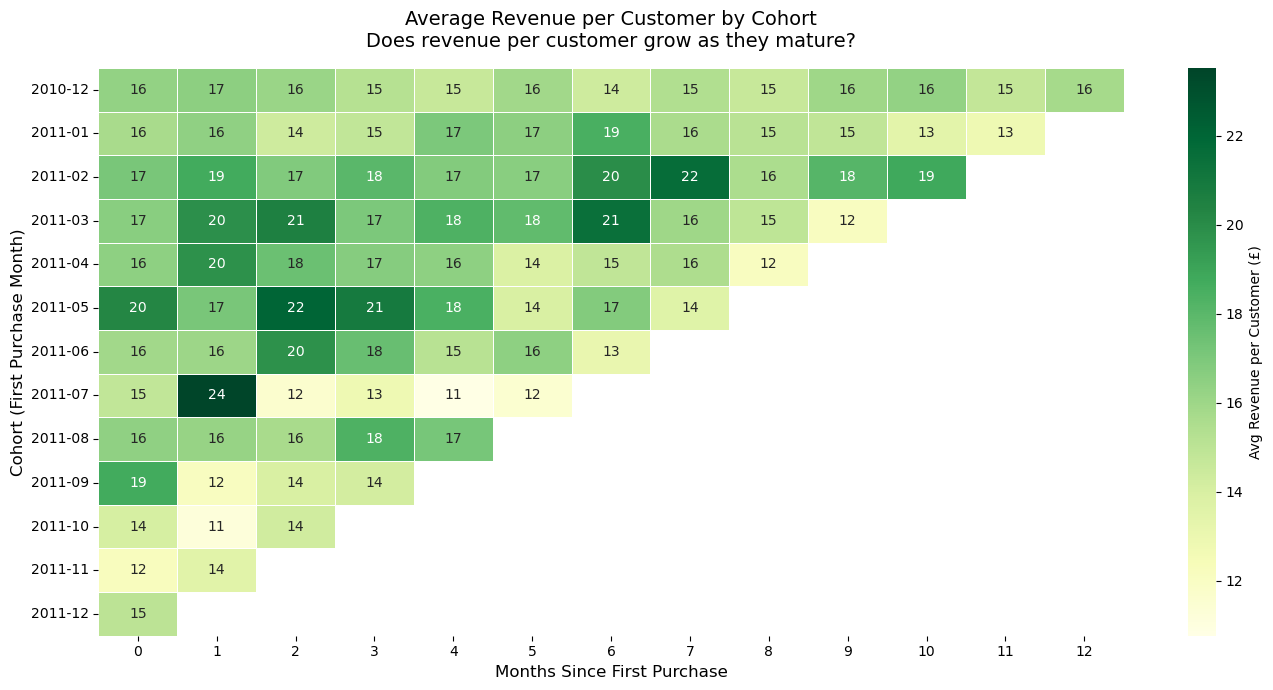

In [31]:
# average revenue per customer per cohort month - CLEAN DATA
revenue_data_clean = df_clean.groupby(['CohortMonth', 'CohortIndex'])['Revenue'].mean().reset_index()
revenue_matrix_clean = revenue_data_clean.pivot(index='CohortMonth', columns='CohortIndex', values='Revenue').round(2)

plt.figure(figsize=(14, 7))
sns.heatmap(
    revenue_matrix_clean,
    annot=True,
    fmt='.0f',
    cmap='YlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Avg Revenue per Customer (£)'}
)
plt.title('Average Revenue per Customer by Cohort\nDoes revenue per customer grow as they mature?',
          fontsize=14, pad=15)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort (First Purchase Month)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('revenue_heatmap_clean.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# average monthly revenue per retained customer across all cohorts
avg_monthly_revenue = revenue_matrix_clean.iloc[:, 1:].mean().mean()
print(f'Average monthly revenue per returning customer: £{avg_monthly_revenue:.2f}')

Average monthly revenue per returning customer: £15.85


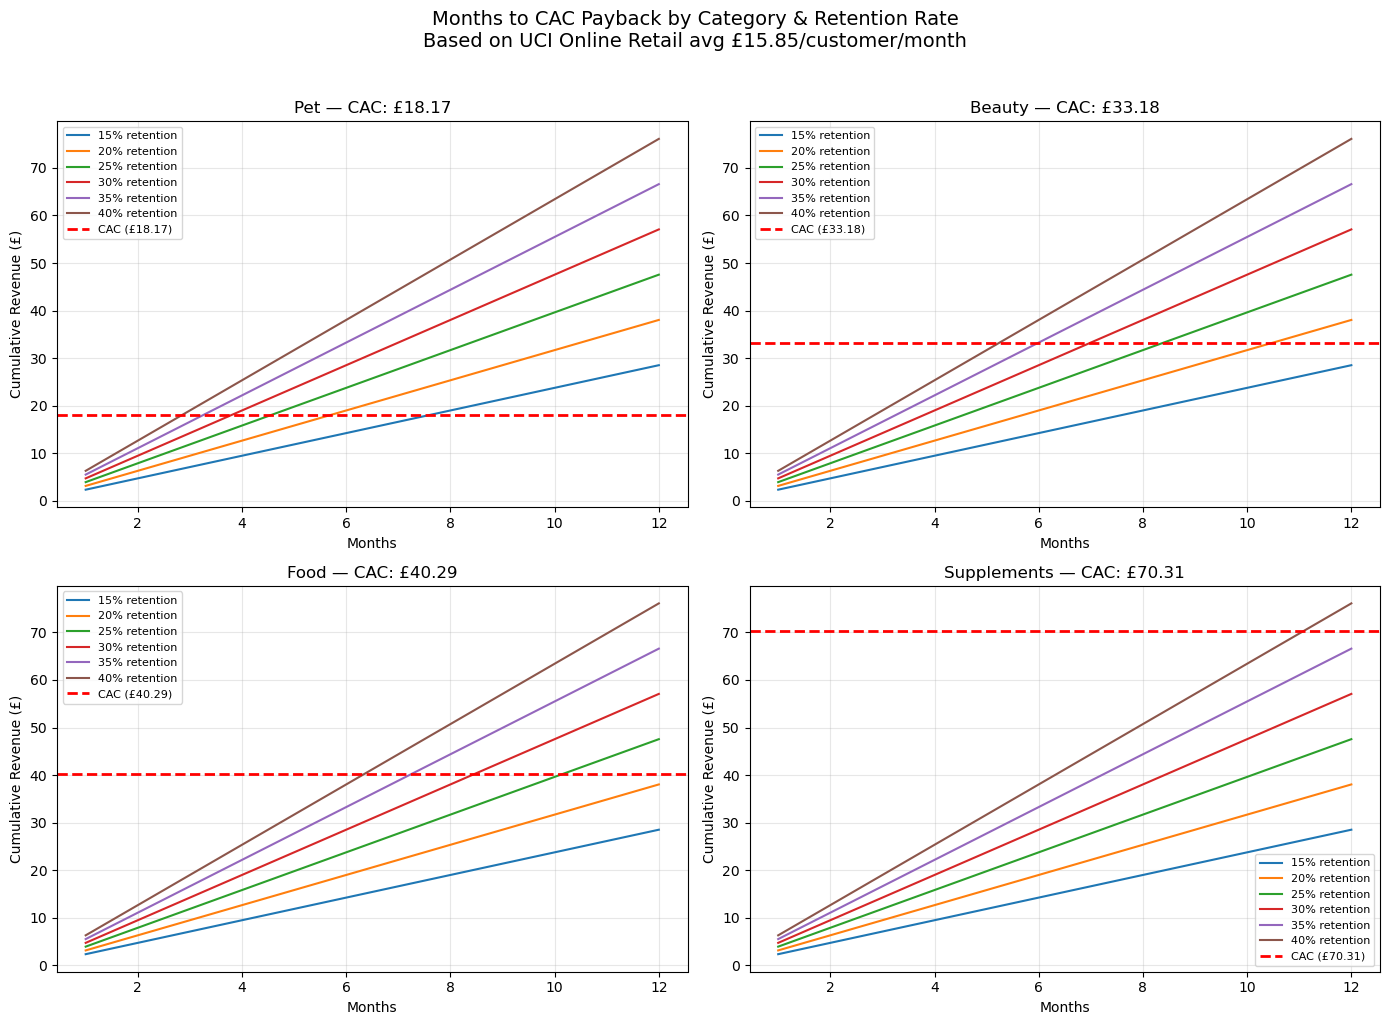

In [35]:
# CAC break-even model
import numpy as np
import matplotlib.pyplot as plt

# real-world DTC CAC benchmarks (USD, converted roughly to GBP at 0.79)
categories = ['Pet', 'Beauty', 'Food', 'Supplements']
cac_usd = [23, 42, 51, 89]
cac_gbp = [round(c * 0.79, 2) for c in cac_usd]

avg_monthly_rev = 15.85

# retention rates to model
retention_rates = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
months = np.arange(1, 13)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (cat, cac) in enumerate(zip(categories, cac_gbp)):
    ax = axes[i]
    
    for ret in retention_rates:
        cumulative_revenue = [avg_monthly_rev * ret * m for m in months]
        ax.plot(months, cumulative_revenue, label=f'{int(ret*100)}% retention')
    
    ax.axhline(y=cac, color='red', linestyle='--', linewidth=2, label=f'CAC (£{cac})')
    ax.set_title(f'{cat} — CAC: £{cac}', fontsize=12)
    ax.set_xlabel('Months')
    ax.set_ylabel('Cumulative Revenue (£)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Months to CAC Payback by Category & Retention Rate\nBased on UCI Online Retail avg £15.85/customer/month',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('cac_breakeven.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# break-even month table
# Supplement brands need 40% retention just to break even in a year. The industry average is 28.2%. Do the math."
from itertools import product

results = []

for cat, cac in zip(categories, cac_gbp):
    for ret in retention_rates:
        breakeven_month = None
        for m in months:
            cumrev = avg_monthly_rev * ret * m
            if cumrev >= cac:
                breakeven_month = m
                break
        results.append({
            'Category': cat,
            'CAC (£)': cac,
            'Retention Rate': f'{int(ret*100)}%',
            'Break-even Month': breakeven_month if breakeven_month else 'Never in 12mo'
        })

breakeven_df = pd.DataFrame(results)
pivot_table = breakeven_df.pivot(index='Retention Rate', columns='Category', values='Break-even Month')

# style it
pivot_table.style\
    .set_caption('Months to CAC Payback by Category & Retention Rate')\
    .highlight_null(color='#ffcccc')\
    .background_gradient(cmap='RdYlGn', axis=None)

Category,Beauty,Food,Pet,Supplements
Retention Rate,,,,
15%,Never in 12mo,Never in 12mo,8,Never in 12mo
20%,11,Never in 12mo,6,Never in 12mo
25%,9,11,5,Never in 12mo
30%,7,9,4,Never in 12mo
35%,6,8,4,Never in 12mo
40%,6,7,3,12


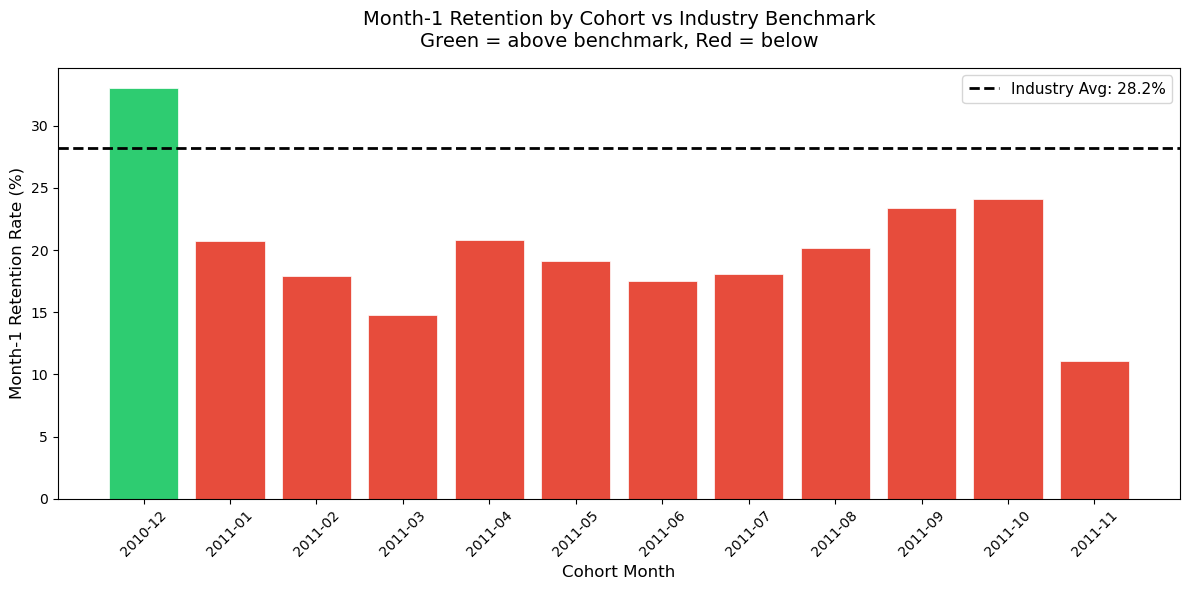

In [39]:
# month 1 retention by cohort vs industry benchmark
month1_retention = retention_matrix_clean[1].dropna()

plt.figure(figsize=(12, 6))

bars = plt.bar(
    month1_retention.index.astype(str),
    month1_retention.values * 100,
    color=['#2ecc71' if x >= 0.282 else '#e74c3c' for x in month1_retention.values],
    edgecolor='white',
    linewidth=0.5
)

plt.axhline(y=28.2, color='black', linestyle='--', linewidth=2, label='Industry Avg: 28.2%')

plt.title('Month-1 Retention by Cohort vs Industry Benchmark\nGreen = above benchmark, Red = below', 
          fontsize=14, pad=15)
plt.xlabel('Cohort Month', fontsize=12)
plt.ylabel('Month-1 Retention Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('month1_retention_vs_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()